# DATATHON 2026 — EDA: Customer Behavior Analytics for Profitable Growth



In [416]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

DATA_DIR_CANDIDATES = [
    Path(r"D:\thao\d\datathon-2026-F.E.N.S\datathon-2026-round-1"),
    Path("/kaggle/input/datathon-2026-round-1"),

]

for candidate in DATA_DIR_CANDIDATES:
    if candidate.exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Khong tim thay thu muc dataset. Hay cap nhat DATA_DIR_CANDIDATES cho dung may cua ban."
    )

print(f"Using dataset from: {DATA_DIR}")


Using dataset from: D:\thao\d\datathon-2026-F.E.N.S\datathon-2026-round-1


In [417]:
TABLE_FILES = {
    "products": "products.csv",
    "customers": "customers.csv",
    "promotions": "promotions.csv",
    "geography": "geography.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "sample_submission": "sample_submission.csv",
    "inventory": "inventory.csv",
    "web_traffic": "web_traffic.csv",
}

DATE_COLUMNS = {
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
}


def load_tables(data_dir, table_files, date_columns):
    tables = {}
    for table_name, file_name in table_files.items():
        tables[table_name] = pd.read_csv(
            data_dir / file_name,
            parse_dates=date_columns.get(table_name),
        )
    return tables


tables = load_tables(DATA_DIR, TABLE_FILES, DATE_COLUMNS)

products = tables["products"]
customers = tables["customers"]
promotions = tables["promotions"]
geography = tables["geography"]
orders = tables["orders"]
order_items = tables["order_items"]
payments = tables["payments"]
shipments = tables["shipments"]
returns = tables["returns"]
reviews = tables["reviews"]
sales = tables["sales"]
sample_sub = tables["sample_submission"]
inventory = tables["inventory"]
web_traffic = tables["web_traffic"]

print("=== DATASET OVERVIEW ===")
for table_name, table_df in tables.items():
    print(f"{table_name:20s} shape = {table_df.shape}")


=== DATASET OVERVIEW ===
products             shape = (2412, 8)
customers            shape = (121930, 7)
promotions           shape = (50, 10)
geography            shape = (39948, 4)
orders               shape = (646945, 8)
order_items          shape = (714669, 7)
payments             shape = (646945, 4)
shipments            shape = (566067, 4)
returns              shape = (39939, 7)
reviews              shape = (113551, 7)
sales                shape = (3833, 3)
sample_submission    shape = (548, 3)
inventory            shape = (60247, 17)
web_traffic          shape = (3652, 7)


## Helper Functions & Theme

- Mục tiêu: chuẩn hóa theme Datathon, helper formatting, và style biểu đồ để toàn bộ notebook nhìn thống nhất.



In [418]:
PALETTE = {
    "black": "#171717",
    "dark_gray": "#2B2B2B",
    "green": "#8CFF5A",
    "lime_green": "#A3FF6A",
    "white": "#FFFFFF",
    "light_gray": "#F2F4F3",
    "mid_gray": "#B8B8B8",
    "risk_red": "#FF5A5F",
    "warning": "#FFB020",
    "info_blue": "#4DA3FF",
    "base_bar": "#5A6472",
}

plt.rcParams.update(
    {
        "figure.facecolor": PALETTE["white"],
        "axes.facecolor": PALETTE["light_gray"],
        "axes.edgecolor": PALETTE["dark_gray"],
        "axes.labelcolor": PALETTE["black"],
        "axes.grid": True,
        "grid.color": PALETTE["mid_gray"],
        "grid.alpha": 0.4,
        "grid.linestyle": "--",
        "text.color": PALETTE["black"],
        "xtick.color": PALETTE["dark_gray"],
        "ytick.color": PALETTE["dark_gray"],
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "legend.fontsize": 11,
    }
)
sns.set_theme(style="whitegrid")


def clean_axis(ax, xlabel: str = "", ylabel: str = "", title: str = "") -> None:
    if title:
        ax.set_title(title, fontsize=14, fontweight="bold", color=PALETTE["black"], pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, color=PALETTE["dark_gray"])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12, color=PALETTE["dark_gray"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def add_bar_labels(ax, fmt="{:.1f}", unit: str = "", pct: bool = False, y_padding: float | None = None):
    heights = [patch.get_height() for patch in ax.patches if not np.isnan(patch.get_height())]
    if not heights:
        return
    offset = y_padding if y_padding is not None else max(heights) * 0.015
    for patch in ax.patches:
        value = patch.get_height()
        if np.isnan(value):
            continue
        label = f"{value:.1f}%" if pct else fmt.format(value)
        label += unit
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + offset,
            label,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=PALETTE["dark_gray"],
        )


def add_hbar_labels(ax, fmt="{:.1f}", pct: bool = False):
    for patch in ax.patches:
        value = patch.get_width()
        if np.isnan(value):
            continue
        label = f"{value:.1f}%" if pct else fmt.format(value)
        ax.annotate(
            label,
            xy=(value, patch.get_y() + patch.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=PALETTE["dark_gray"],
        )


def count_frame(series: pd.Series, label: str) -> pd.DataFrame:
    counts = series.fillna("Unknown").astype(str).value_counts()
    return counts.rename_axis(label).reset_index(name="count")


## Tổng quan nhanh về dữ liệu

Phần này tập trung vào các biểu đồ đếm cơ bản để nhìn nhanh cấu trúc dữ liệu trước khi đi vào phân tích sâu hơn.


#### Danh mục sản phẩm phân bố như thế nào?



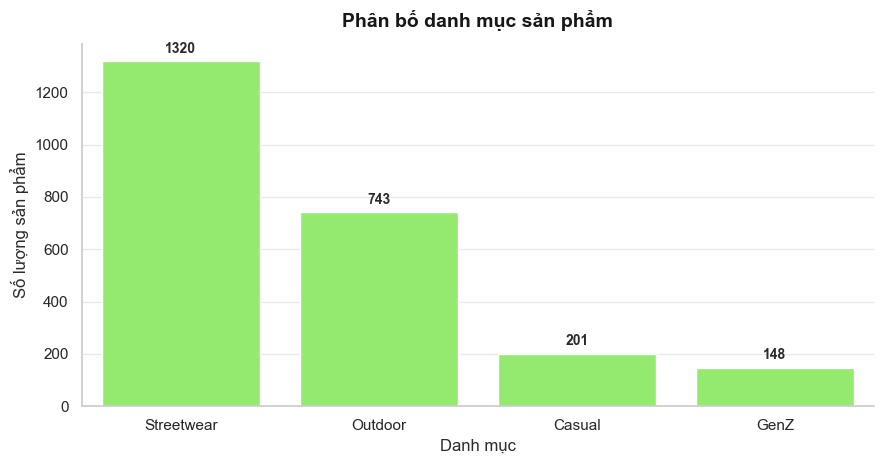

In [419]:
category_counts = count_frame(products["category"], "category")

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=category_counts,
    x="category",
    y="count",
    color=PALETTE["green"],
    ax=ax,
)
clean_axis(ax, xlabel="Danh mục", ylabel="Số lượng sản phẩm", title="Phân bố danh mục sản phẩm")
ax.tick_params(axis="x")
add_bar_labels(ax, fmt="{:.0f}")
plt.tight_layout()
plt.show()


In [420]:
def plot_count_chart(
    df,
    column,
    title,
    xlabel,
    top_n=None,
    color_key="green",
    rotation=0,
    horizontal=False,
    figsize=None,
):
    plot_data = count_frame(df[column], column)
    if top_n is not None:
        plot_data = plot_data.head(top_n)

    if horizontal:
        fig, ax = plt.subplots(figsize=figsize or (10, 5.6))
        sns.barplot(
            data=plot_data,
            y=column,
            x="count",
            color=PALETTE[color_key],
            ax=ax,
        )
        clean_axis(ax, xlabel="Số lượng", ylabel=xlabel, title=title)
        add_hbar_labels(ax, fmt="{:.0f}")
    else:
        fig, ax = plt.subplots(figsize=figsize or (9, 4.8))
        sns.barplot(
            data=plot_data,
            x=column,
            y="count",
            color=PALETTE[color_key],
            ax=ax,
        )
        clean_axis(ax, xlabel=xlabel, ylabel="Số lượng", title=title)
        ax.tick_params(axis="x", rotation=rotation)
        add_bar_labels(ax, fmt="{:.0f}")

    plt.tight_layout()
    plt.show()


#### Segment sản phẩm phân bố như thế nào?


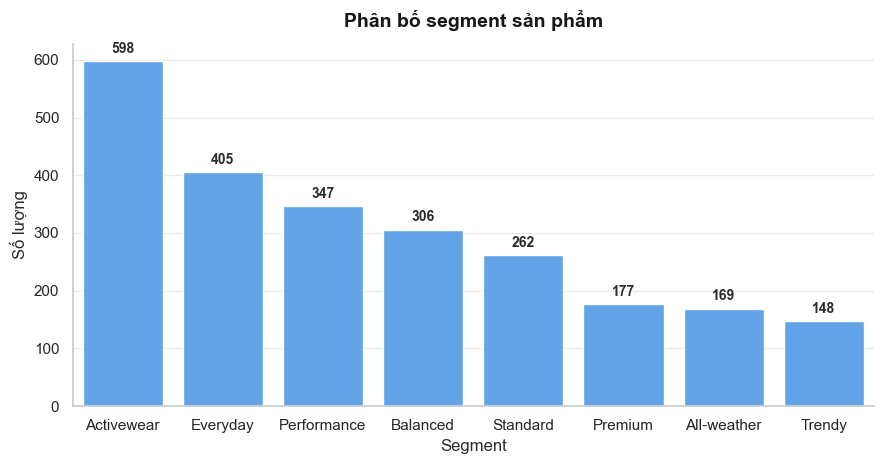

In [421]:
plot_count_chart(
    products,
    "segment",
    "Phân bố segment sản phẩm",
    "Segment",
    color_key="info_blue",
)


#### Khách hàng đến từ những thành phố nào?



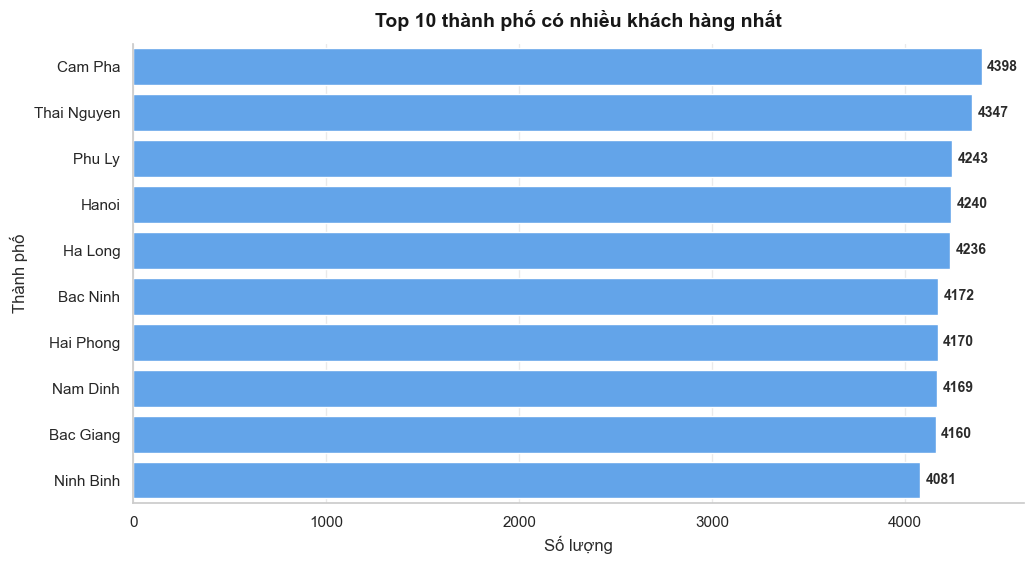

In [422]:
plot_count_chart(
    customers,
    "city",
    "Top 10 thành phố có nhiều khách hàng nhất",
    "Thành phố",
    top_n=10,
    color_key="info_blue",
    horizontal=True,
    figsize=(10.5, 5.8),
)


#### Giới tính của khách hàng phân bố ra sao?



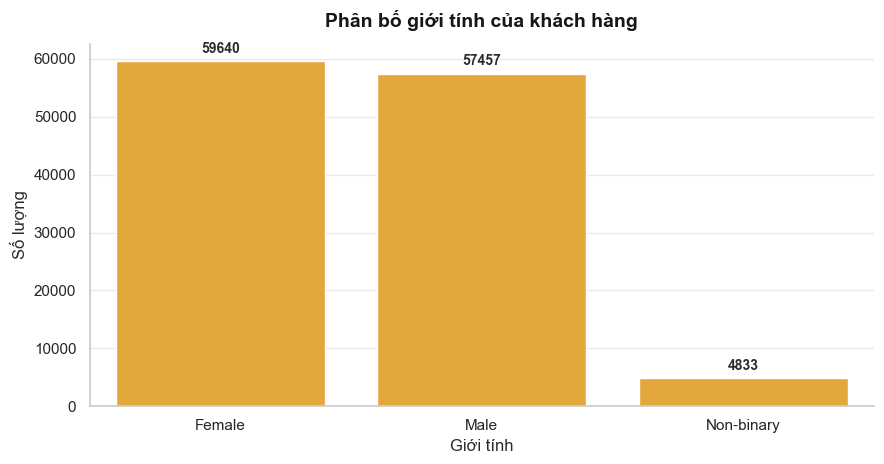

In [423]:
plot_count_chart(
    customers,
    "gender",
    "Phân bố giới tính của khách hàng",
    "Giới tính",
    color_key="warning",
)


#### Nhóm tuổi nào phổ biến hơn?


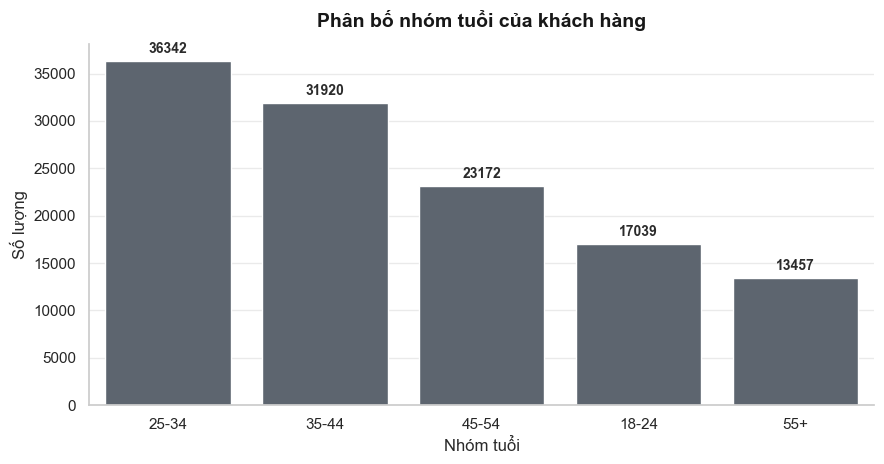

In [424]:
plot_count_chart(
    customers,
    "age_group",
    "Phân bố nhóm tuổi của khách hàng",
    "Nhóm tuổi",
    color_key="base_bar",
)


#### Trạng thái đơn hàng nào xuất hiện nhiều?


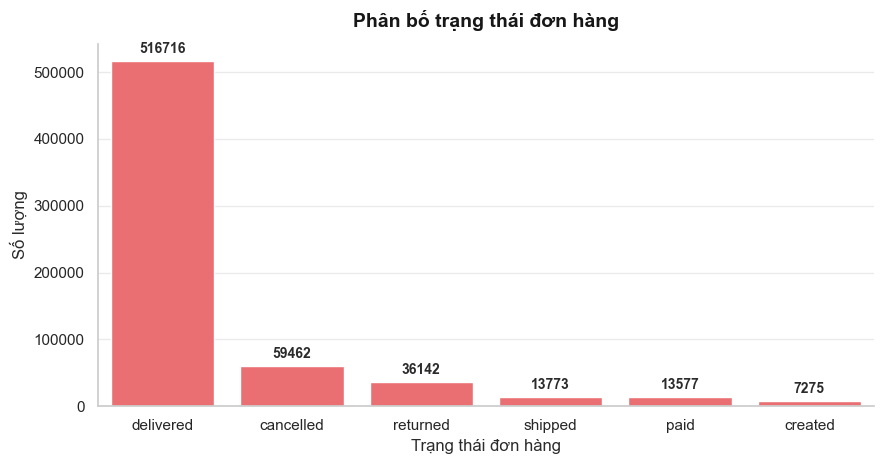

In [425]:
plot_count_chart(
    orders,
    "order_status",
    "Phân bố trạng thái đơn hàng",
    "Trạng thái đơn hàng",
    color_key="risk_red",
)


#### Phương thức thanh toán nào được ghi nhận?


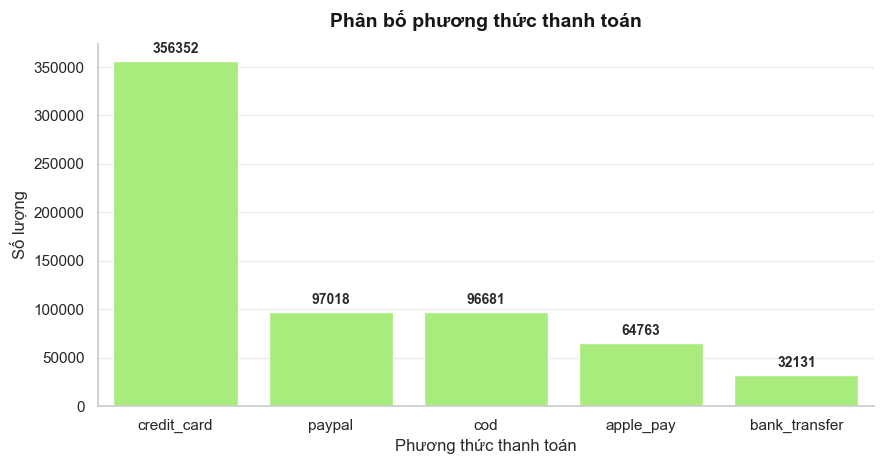

In [426]:
plot_count_chart(
    orders,
    "payment_method",
    "Phân bố phương thức thanh toán",
    "Phương thức thanh toán",
    color_key="lime_green",
)


#### Nguồn đơn hàng đến từ đâu?


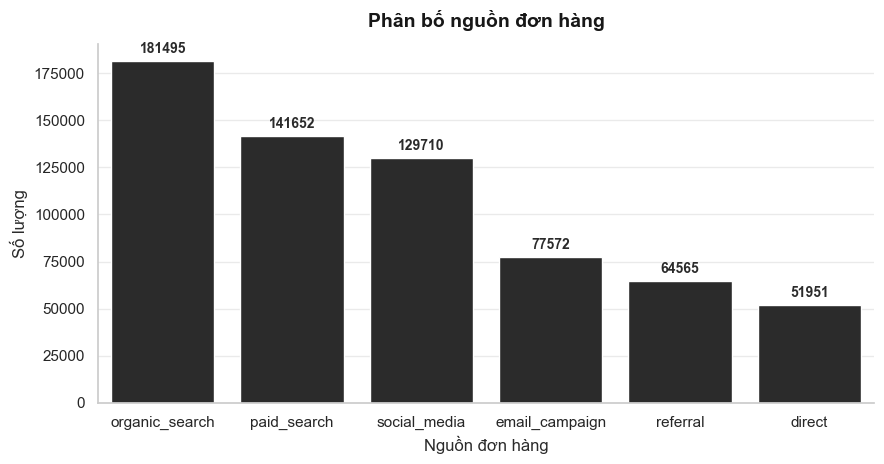

In [427]:
plot_count_chart(
    orders,
    "order_source",
    "Phân bố nguồn đơn hàng",
    "Nguồn đơn hàng",
    color_key="dark_gray",
)


# EDA


## Business Overview: Doanh nghiệp đang kiếm tiền như thế nào?

- Tập trung vào Revenue, Order Volume, AOV, COGS, Gross Profit, Gross Margin và Seasonality.
- Revenue được xây từ transaction tables: `orders`, `order_items`, `products`.
- COGS is calculated using product-level unit cost from the `products` table.


### 1. Chuẩn bị business metrics


In [428]:
orders_eda = orders.copy()
order_items_eda = order_items.copy()
products_eda = products.copy()

product_cols = ["product_id", "category", "segment", "price", "cogs"]
order_fact = orders_eda.merge(order_items_eda, on="order_id", how="inner")
order_fact = order_fact.merge(products_eda[product_cols], on="product_id", how="left")
order_fact = order_fact.rename(columns={"cogs": "product_unit_cogs"})

order_fact["gross_line_sales"] = order_fact["quantity"] * order_fact["unit_price"] #doanh thu gộp trước chiết khấu
order_fact["line_revenue"] = order_fact["gross_line_sales"] - order_fact["discount_amount"] #doanh thu sau chiết khấu
order_fact["discount_rate"] = order_fact["discount_amount"] / order_fact["gross_line_sales"].replace(0, np.nan) #tỷ lệ chiết khấu trên doanh thu gộp
order_fact["line_cogs"] = order_fact["quantity"] * order_fact["product_unit_cogs"] #tổng giá vốn của dòng hàng
order_fact["line_gross_profit"] = order_fact["line_revenue"] - order_fact["line_cogs"] #lợi nhuận gộp của dòng hàng
order_fact["line_gross_margin"] = order_fact["line_gross_profit"] / order_fact["line_revenue"].replace(0, np.nan) #Biên lợi nhuận gộp trên doanh thu của dòng hàng

order_fact["year"] = order_fact["order_date"].dt.year
order_fact["month"] = order_fact["order_date"].dt.month
order_fact["month_name"] = order_fact["order_date"].dt.strftime("%b")
order_fact["year_month"] = order_fact["order_date"].dt.to_period("M").dt.to_timestamp()


def aggregate_business(frame: pd.DataFrame, group_key: str) -> pd.DataFrame:
    return (
        frame.groupby(group_key, as_index=False)
        .agg(
            revenue=("line_revenue", "sum"),
            gross_line_sales=("gross_line_sales", "sum"),
            discount_amount=("discount_amount", "sum"),
            cogs=("line_cogs", "sum"),
            gross_profit=("line_gross_profit", "sum"),
            order_count=("order_id", pd.Series.nunique),
            customer_count=("customer_id", pd.Series.nunique),
            total_quantity=("quantity", "sum"),
        )
    )


def add_business_ratios(df: pd.DataFrame, growth_prefix: str) -> pd.DataFrame:
    df = df.copy()
    df["gross_margin"] = df["gross_profit"] / df["revenue"].replace(0, np.nan) #Biên lợi nhuận gộp trên doanh thu
    df["discount_rate"] = df["discount_amount"] / df["gross_line_sales"].replace(0, np.nan) #tỷ lệ chiết khấu trên doanh thu gộp
    df["aov"] = df["revenue"] / df["order_count"].replace(0, np.nan) #Average Order Value
    df["units_per_order"] = df["total_quantity"] / df["order_count"].replace(0, np.nan) #Số lượng trung bình trên mỗi đơn hàng
    df["revenue_per_unit"] = df["revenue"] / df["total_quantity"].replace(0, np.nan) #Doanh thu trung bình trên mỗi đơn vị hàng hóa
    df[f"{growth_prefix}_revenue_growth"] = df["revenue"].pct_change() #Tăng trưởng doanh thu theo chu kỳ (MoM hoặc YoY)
    df[f"{growth_prefix}_gross_profit_growth"] = df["gross_profit"].pct_change() #Tăng trưởng lợi nhuận gộp so với kỳ trước
    df["margin_change"] = df["gross_margin"].diff()
    return df


monthly_business = aggregate_business(order_fact, "year_month").sort_values("year_month").reset_index(drop=True)
monthly_business = add_business_ratios(monthly_business, "mom")
monthly_business["year"] = monthly_business["year_month"].dt.year
monthly_business["month"] = monthly_business["year_month"].dt.month
monthly_business["month_name"] = monthly_business["year_month"].dt.strftime("%b")
monthly_business["month_label"] = "T" + monthly_business["month"].astype(str)

yearly_business = aggregate_business(order_fact, "year").sort_values("year").reset_index(drop=True)
yearly_business = add_business_ratios(yearly_business, "yoy")

calendar_month_revenue = (
    monthly_business.groupby(["month", "month_name"], as_index=False)["revenue"]
    .mean()
    .rename(columns={"revenue": "avg_revenue"})
    .sort_values("month")
)
calendar_month_revenue["month_label"] = "T" + calendar_month_revenue["month"].astype(str)

margin_pressure_months = monthly_business.loc[
    (monthly_business["mom_revenue_growth"] > 0) & (monthly_business["margin_change"] < 0)
].copy()
margin_pressure_months = margin_pressure_months.sort_values(
    ["mom_revenue_growth", "margin_change"], ascending=[False, True]
).reset_index(drop=True)


def format_currency(value):
    return "N/A" if pd.isna(value) else f"{value:,.0f}"


def format_number(value):
    return "N/A" if pd.isna(value) else f"{value:,.0f}"


def format_pct(value):
    return "N/A" if pd.isna(value) else f"{value:.2%}"


def format_period(value):
    return "N/A" if pd.isna(value) else pd.to_datetime(value).strftime("%Y-%m")


### 2. KPI Snapshot


In [429]:
best_revenue_year_row = yearly_business.loc[yearly_business["revenue"].idxmax()]
best_revenue_month_row = monthly_business.loc[monthly_business["revenue"].idxmax()]

kpi_snapshot = pd.DataFrame(
    {
        "KPI": [
            "Total Revenue",
            "Total COGS",
            "Total Gross Profit",
            "Overall Gross Margin",
            "Total Orders",
            "Total Customers",
            "Total Units Sold",
            "Average Order Value",
            "Average Units per Order",
            "First Order Date",
            "Last Order Date",
            "Best Revenue Year",
            "Best Revenue Month",
        ],
        "Giá trị": [
            format_currency(monthly_business["revenue"].sum()),
            format_currency(monthly_business["cogs"].sum()),
            format_currency(monthly_business["gross_profit"].sum()),
            format_pct(monthly_business["gross_profit"].sum() / monthly_business["revenue"].sum()),
            format_number(orders_eda["order_id"].nunique()),
            format_number(order_fact["customer_id"].nunique()),
            format_number(order_fact["quantity"].sum()),
            format_currency(monthly_business["revenue"].sum() / orders_eda["order_id"].nunique()),
            f"{order_fact['quantity'].sum() / orders_eda['order_id'].nunique():.2f}",
            orders_eda["order_date"].min().strftime("%Y-%m-%d"),
            orders_eda["order_date"].max().strftime("%Y-%m-%d"),
            f"{int(best_revenue_year_row['year'])} ({format_currency(best_revenue_year_row['revenue'])})",
            f"{format_period(best_revenue_month_row['year_month'])} ({format_currency(best_revenue_month_row['revenue'])})",
        ],
    }
)

display(kpi_snapshot)


,KPI,Giá trị
0,Total Revenue,"15,680,869,265"
1,Total COGS,"14,163,450,519"
2,Total Gross Profit,"1,517,418,746"
3,Overall Gross Margin,9.68%
4,Total Orders,"646,945"
5,Total Customers,"90,246"
6,Total Units Sold,"3,213,143"
7,Average Order Value,"24,238"
8,Average Units per Order,4.97
9,First Order Date,2012-07-04


### 3. Revenue và Gross Profit thay đổi thế nào theo thời gian?

Biểu đồ dưới đây dùng để nhìn xu hướng Revenue và Gross Profit theo tháng trước khi đào sâu vào cấu trúc tăng trưởng.


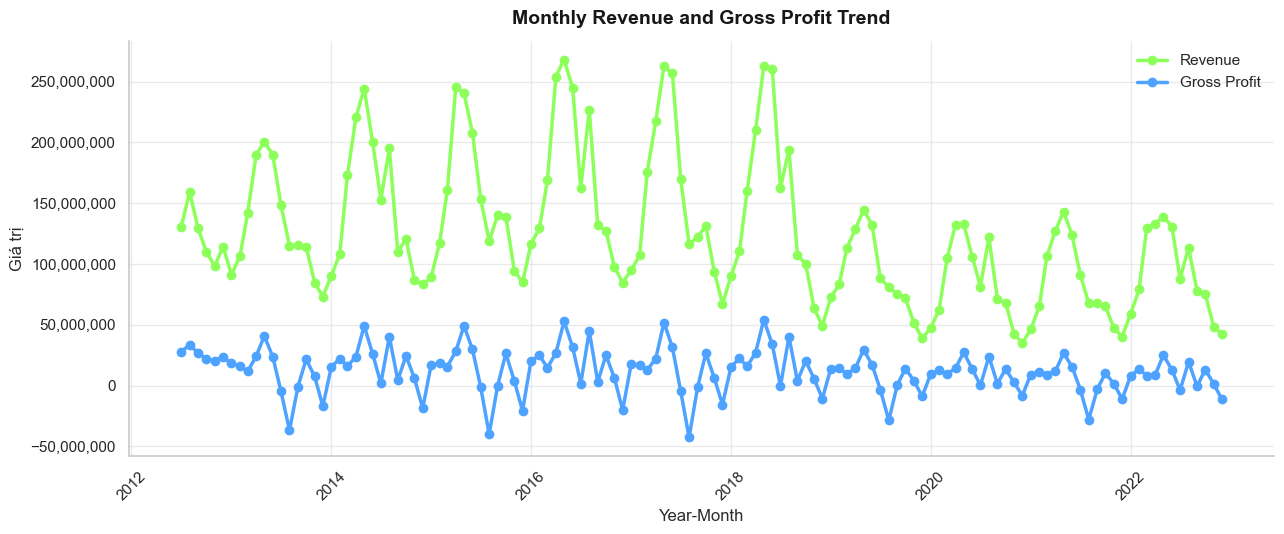

Tháng revenue cao nhất: 2016-05 - 268,131,884
Tháng gross profit cao nhất: 2018-05 - 54,184,728
Tháng revenue thấp nhất: 2020-12 - 34,953,775
Năm revenue cao nhất: 2016 - 2,012,364,466
Năm gross margin cao nhất: 2012 - 20.77%
Năm gross margin thấp nhất: 2021 - 5.05%


In [430]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(
    monthly_business["year_month"],
    monthly_business["revenue"],
    color=PALETTE["green"],
    linewidth=2.5,
    marker="o",
    label="Revenue",
)
ax.plot(
    monthly_business["year_month"],
    monthly_business["gross_profit"],
    color=PALETTE["info_blue"],
    linewidth=2.5,
    marker="o",
    label="Gross Profit",
)
clean_axis(ax, xlabel="Year-Month", ylabel="Giá trị", title="Monthly Revenue and Gross Profit Trend")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

best_revenue_month = monthly_business.loc[monthly_business["revenue"].idxmax()]
best_gp_month = monthly_business.loc[monthly_business["gross_profit"].idxmax()]
lowest_revenue_month = monthly_business.loc[monthly_business["revenue"].idxmin()]
best_revenue_year = yearly_business.loc[yearly_business["revenue"].idxmax()]
best_margin_year = yearly_business.loc[yearly_business["gross_margin"].idxmax()]
lowest_margin_year = yearly_business.loc[yearly_business["gross_margin"].idxmin()]

print("Tháng revenue cao nhất:", format_period(best_revenue_month["year_month"]), "-", format_currency(best_revenue_month["revenue"]))
print("Tháng gross profit cao nhất:", format_period(best_gp_month["year_month"]), "-", format_currency(best_gp_month["gross_profit"]))
print("Tháng revenue thấp nhất:", format_period(lowest_revenue_month["year_month"]), "-", format_currency(lowest_revenue_month["revenue"]))
print("Năm revenue cao nhất:", int(best_revenue_year["year"]), "-", format_currency(best_revenue_year["revenue"]))
print("Năm gross margin cao nhất:", int(best_margin_year["year"]), "-", format_pct(best_margin_year["gross_margin"]))
print("Năm gross margin thấp nhất:", int(lowest_margin_year["year"]), "-", format_pct(lowest_margin_year["gross_margin"]))


#### Key Findings Template

- Revenue peaked in ___, reaching ___.
- Gross profit peaked in ___, reaching ___.
- The gap between revenue and gross profit suggests ___.


### 4. Doanh thu tăng trưởng theo năm có đi cùng lợi nhuận không?

Biểu đồ này đối chiếu Revenue, Gross Profit và Gross Margin ở cấp năm để xem tăng trưởng có đi cùng hiệu quả lợi nhuận hay không.


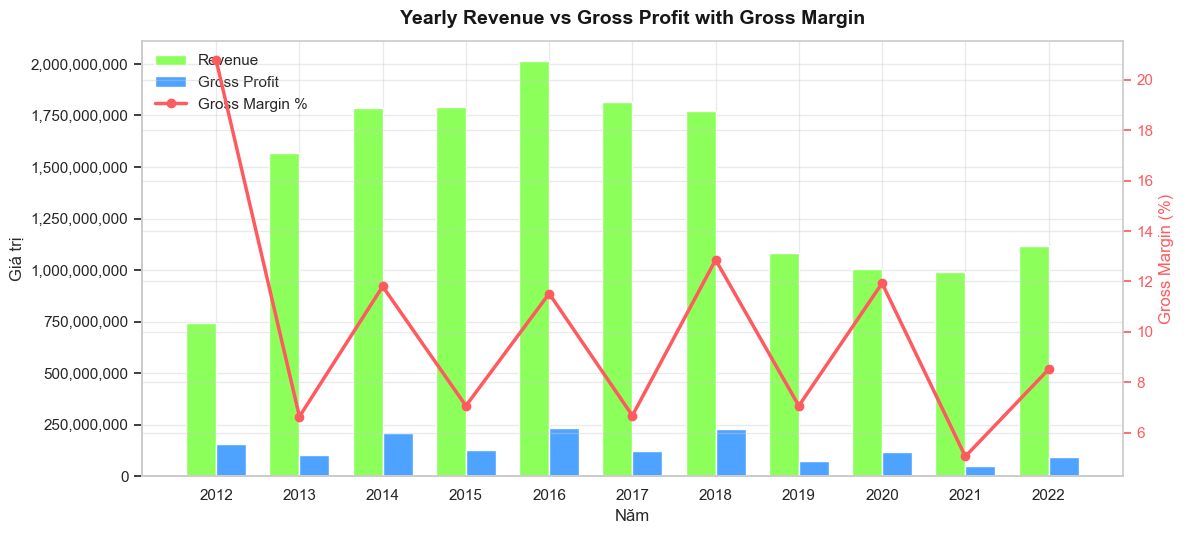

Năm revenue cao nhất: 2016 - 2,012,364,466
Năm gross profit cao nhất: 2016 - 231,805,073
Năm gross margin thấp nhất: 2021 - 5.05%
Năm có YoY revenue growth cao nhất: 2013 - 111.76%
Các năm revenue tăng nhưng gross margin giảm:


,year,revenue,gross_margin,yoy_revenue_growth,margin_change
1,2013,"1,570,165,169",6.64%,111.76%,-14.14%
3,2015,"1,792,009,967",7.06%,0.37%,-4.74%


In [431]:
year_positions = np.arange(len(yearly_business))
bar_width = 0.36

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax1.bar(
    year_positions - bar_width / 2,
    yearly_business["revenue"],
    width=bar_width,
    color=PALETTE["green"],
    label="Revenue",
)
ax1.bar(
    year_positions + bar_width / 2,
    yearly_business["gross_profit"],
    width=bar_width,
    color=PALETTE["info_blue"],
    label="Gross Profit",
)
clean_axis(ax1, xlabel="Năm", ylabel="Giá trị", title="Yearly Revenue vs Gross Profit with Gross Margin")
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax1.set_xticks(year_positions)
ax1.set_xticklabels(yearly_business["year"].astype(int).astype(str))

ax2 = ax1.twinx()
ax2.plot(
    year_positions,
    yearly_business["gross_margin"] * 100,
    color=PALETTE["risk_red"],
    linewidth=2.5,
    marker="o",
    label="Gross Margin %",
)
ax2.set_ylabel("Gross Margin (%)", color=PALETTE["risk_red"])
ax2.tick_params(axis="y", colors=PALETTE["risk_red"])

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

best_year_revenue = yearly_business.loc[yearly_business["revenue"].idxmax()]
best_year_gp = yearly_business.loc[yearly_business["gross_profit"].idxmax()]
lowest_year_margin = yearly_business.loc[yearly_business["gross_margin"].idxmin()]
best_yoy_growth = yearly_business.dropna(subset=["yoy_revenue_growth"]).loc[
    yearly_business.dropna(subset=["yoy_revenue_growth"])["yoy_revenue_growth"].idxmax()
]
revenue_up_margin_down = yearly_business.loc[
    (yearly_business["yoy_revenue_growth"] > 0) & (yearly_business["margin_change"] < 0),
    ["year", "revenue", "gross_margin", "yoy_revenue_growth", "margin_change"],
].copy()

print("Năm revenue cao nhất:", int(best_year_revenue["year"]), "-", format_currency(best_year_revenue["revenue"]))
print("Năm gross profit cao nhất:", int(best_year_gp["year"]), "-", format_currency(best_year_gp["gross_profit"]))
print("Năm gross margin thấp nhất:", int(lowest_year_margin["year"]), "-", format_pct(lowest_year_margin["gross_margin"]))
print("Năm có YoY revenue growth cao nhất:", int(best_yoy_growth["year"]), "-", format_pct(best_yoy_growth["yoy_revenue_growth"]))

if revenue_up_margin_down.empty:
    print("Không có năm nào revenue tăng nhưng gross margin giảm.")
else:
    print("Các năm revenue tăng nhưng gross margin giảm:")
    display(
        revenue_up_margin_down.assign(
            revenue=revenue_up_margin_down["revenue"].map(format_currency),
            gross_margin=revenue_up_margin_down["gross_margin"].map(format_pct),
            yoy_revenue_growth=revenue_up_margin_down["yoy_revenue_growth"].map(format_pct),
            margin_change=revenue_up_margin_down["margin_change"].map(format_pct),
        )
    )


#### Key Findings Template

- Revenue increased/decreased most strongly in ___.
- Gross margin was lowest in ___, indicating ___.
- This suggests growth was/was not accompanied by profitability improvement.


### 5. Seasonality: tháng nào thường tạo doanh thu cao nhất?

Biểu đồ này gom doanh thu theo tháng trong năm để xem tháng nào thường là peak season về mặt doanh thu.


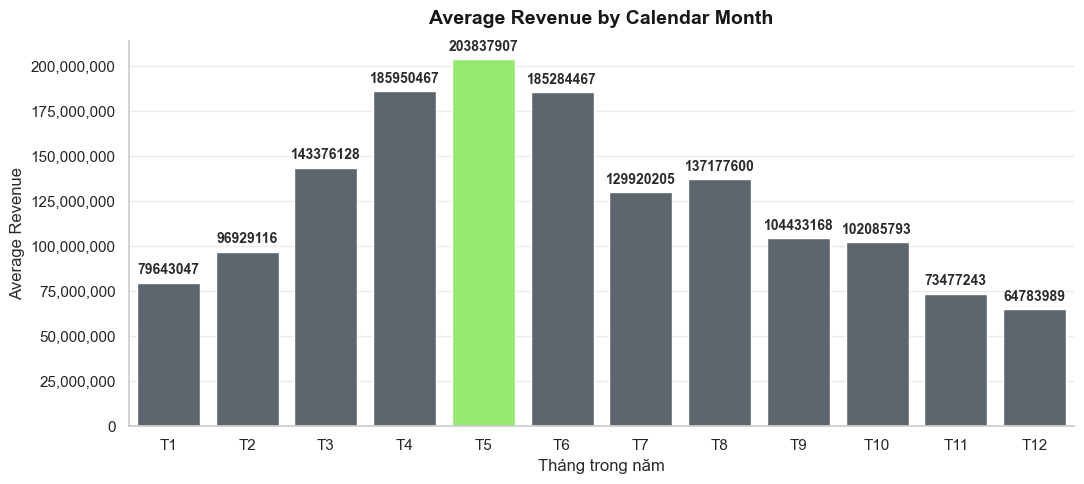

Top 3 tháng có average revenue cao nhất:


,month_label,avg_revenue
4,T5,"203,837,907"
3,T4,"185,950,467"
5,T6,"185,284,467"


Bottom 3 tháng có average revenue thấp nhất:


,month_label,avg_revenue
11,T12,"64,783,989"
10,T11,"73,477,243"
0,T1,"79,643,047"


Chênh lệch giữa tháng cao nhất và mức average monthly revenue: 63.79%


In [432]:
best_calendar_month = calendar_month_revenue.loc[calendar_month_revenue["avg_revenue"].idxmax(), "month"]
bar_colors = [
    PALETTE["green"] if month == best_calendar_month else PALETTE["base_bar"]
    for month in calendar_month_revenue["month"]
]

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=calendar_month_revenue,
    x="month_label",
    y="avg_revenue",
    palette=bar_colors,
    ax=ax,
)
clean_axis(ax, xlabel="Tháng trong năm", ylabel="Average Revenue", title="Average Revenue by Calendar Month")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
add_bar_labels(ax, fmt="{:.0f}")
plt.tight_layout()
plt.show()

top_3_months = calendar_month_revenue.nlargest(3, "avg_revenue")[["month_label", "avg_revenue"]].copy()
bottom_3_months = calendar_month_revenue.nsmallest(3, "avg_revenue")[["month_label", "avg_revenue"]].copy()
overall_avg_monthly_revenue = monthly_business["revenue"].mean()
best_month_row = calendar_month_revenue.loc[calendar_month_revenue["avg_revenue"].idxmax()]
worst_month_row = calendar_month_revenue.loc[calendar_month_revenue["avg_revenue"].idxmin()]
gap_vs_avg = best_month_row["avg_revenue"] / overall_avg_monthly_revenue - 1

print("Top 3 tháng có average revenue cao nhất:")
display(top_3_months.assign(avg_revenue=top_3_months["avg_revenue"].map(format_currency)))

print("Bottom 3 tháng có average revenue thấp nhất:")
display(bottom_3_months.assign(avg_revenue=bottom_3_months["avg_revenue"].map(format_currency)))

print("Chênh lệch giữa tháng cao nhất và mức average monthly revenue:", format_pct(gap_vs_avg))


#### Key Findings Template

- The strongest revenue month is ___.
- The weakest revenue month is ___.
- The gap between peak month and average month is ___, suggesting ___.


### 6. Seasonality có ổn định qua các năm không?

Heatmap giúp kiểm tra xem các tháng cao điểm có lặp lại tương đối ổn định qua nhiều năm hay không.


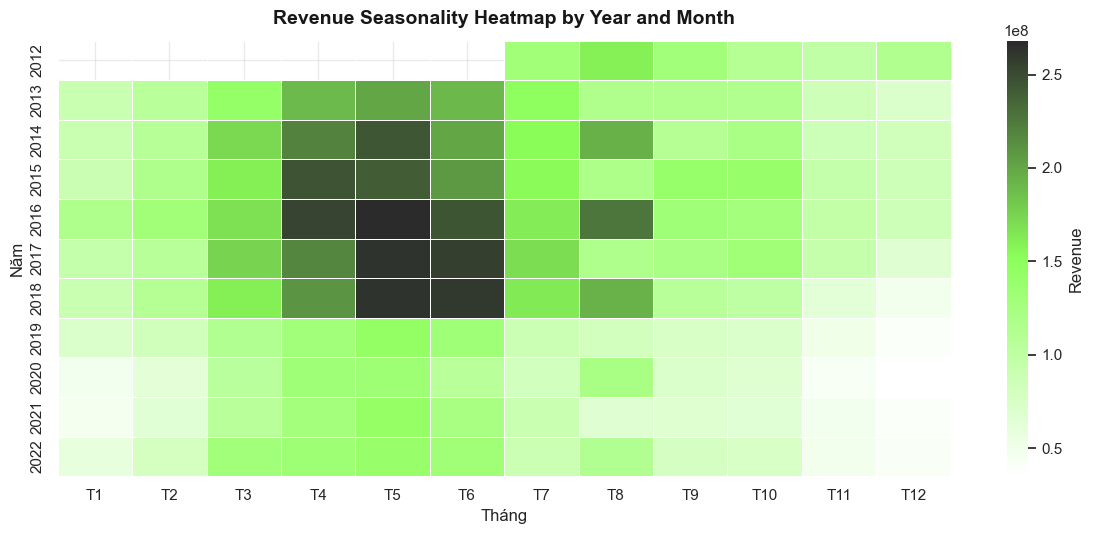

Tháng peak revenue của từng năm:


,year,month,month_label,revenue
1,2012,8,T8,"159,089,240"
10,2013,5,T5,"200,500,109"
22,2014,5,T5,"244,309,542"
33,2015,4,T4,"245,842,300"
46,2016,5,T5,"268,131,884"
58,2017,5,T5,"262,908,846"
70,2018,5,T5,"262,778,503"
82,2019,5,T5,"144,443,148"
94,2020,5,T5,"132,823,768"
106,2021,5,T5,"143,070,695"


Tháng xuất hiện nhiều nhất trong nhóm peak month: T5


In [433]:
seasonality_heatmap = monthly_business.pivot_table(index="year", columns="month", values="revenue", aggfunc="sum")
seasonality_heatmap = seasonality_heatmap.reindex(columns=range(1, 13))

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(
    seasonality_heatmap,
    cmap=sns.blend_palette([PALETTE["white"], PALETTE["green"], PALETTE["dark_gray"]], as_cmap=True),
    linewidths=0.5,
    linecolor=PALETTE["white"],
    cbar_kws={"label": "Revenue"},
    ax=ax,
)
ax.set_title("Revenue Seasonality Heatmap by Year and Month", fontsize=14, fontweight="bold", color=PALETTE["black"], pad=12)
ax.set_xlabel("Tháng")
ax.set_ylabel("Năm")
ax.set_xticklabels([f"T{i}" for i in range(1, 13)], rotation=0)
plt.tight_layout()
plt.show()

peak_month_by_year = monthly_business.loc[
    monthly_business.groupby("year")["revenue"].idxmax(),
    ["year", "month", "month_label", "revenue"],
].sort_values("year")
most_common_peak_month = peak_month_by_year["month_label"].mode().iat[0]

print("Tháng peak revenue của từng năm:")
display(peak_month_by_year.assign(revenue=peak_month_by_year["revenue"].map(format_currency)))
print("Tháng xuất hiện nhiều nhất trong nhóm peak month:", most_common_peak_month)


#### Key Findings Template

- Peak revenue months are concentrated around ___.
- Seasonality appears consistent/inconsistent across years because ___.
- This has implications for campaign planning, inventory and logistics.


### 7. Revenue tăng nhờ order volume hay AOV?

Mục tiêu ở đây là so sánh hai động lực cơ bản của doanh thu: số lượng đơn hàng và giá trị trung bình mỗi đơn.


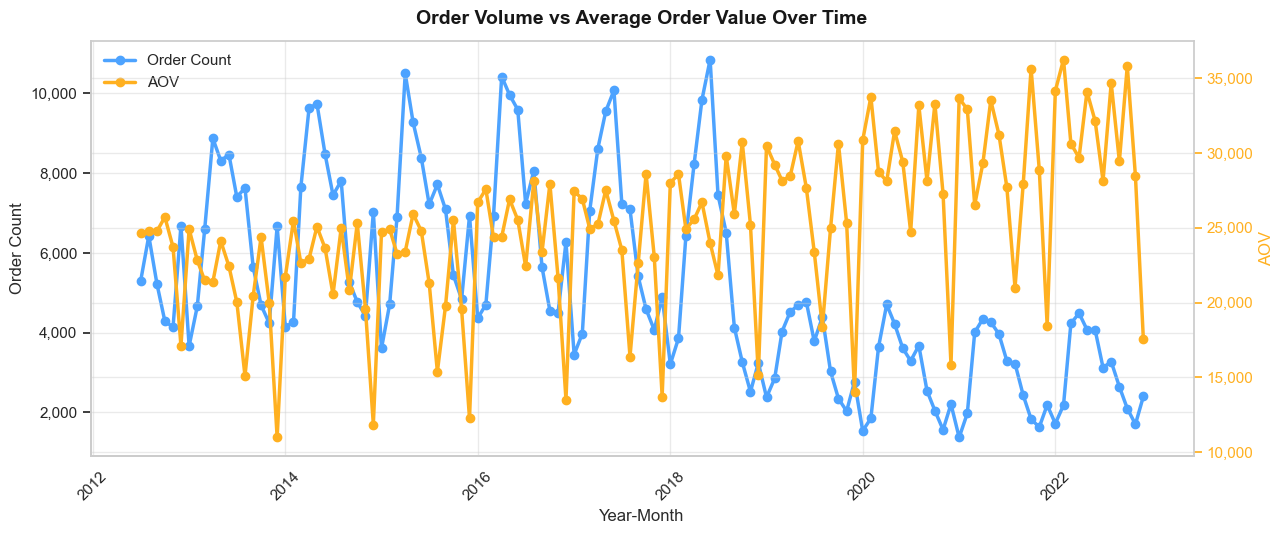

Correlation giữa revenue và order_count: 0.904
Correlation giữa revenue và AOV: 0.021
Kết luận sơ bộ: Revenue có vẻ được drive nhiều hơn bởi order volume so với AOV.
Recommended focus: acquisition, conversion và campaign reach


In [434]:
fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax1.plot(
    monthly_business["year_month"],
    monthly_business["order_count"],
    color=PALETTE["info_blue"],
    linewidth=2.5,
    marker="o",
    label="Order Count",
)
clean_axis(ax1, xlabel="Year-Month", ylabel="Order Count", title="Order Volume vs Average Order Value Over Time")
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    monthly_business["year_month"],
    monthly_business["aov"],
    color=PALETTE["warning"],
    linewidth=2.5,
    marker="o",
    label="AOV",
)
ax2.set_ylabel("AOV", color=PALETTE["warning"])
ax2.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax2.tick_params(axis="y", colors=PALETTE["warning"])

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

corr_revenue_orders = monthly_business[["revenue", "order_count"]].corr().iloc[0, 1]
corr_revenue_aov = monthly_business[["revenue", "aov"]].corr().iloc[0, 1]

if corr_revenue_orders > corr_revenue_aov:
    primary_driver = "order volume"
    secondary_driver = "AOV"
    recommended_focus = "acquisition, conversion và campaign reach"
else:
    primary_driver = "AOV"
    secondary_driver = "order volume"
    recommended_focus = "bundle, upsell, cross-sell và free-shipping threshold"

print("Correlation giữa revenue và order_count:", f"{corr_revenue_orders:.3f}")
print("Correlation giữa revenue và AOV:", f"{corr_revenue_aov:.3f}")
print(f"Kết luận sơ bộ: Revenue có vẻ được drive nhiều hơn bởi {primary_driver} so với {secondary_driver}.")
print("Recommended focus:", recommended_focus)


#### Key Findings Template

- Revenue is more correlated with ___ than ___.
- This suggests revenue growth is mainly driven by ___.
- Recommended focus: ___.


### 8. Có giai đoạn revenue tăng nhưng Gross Margin giảm không?

Scatter plot dưới đây là chart chẩn đoán để tìm những tháng tăng trưởng doanh thu đi kèm với sự co hẹp margin.


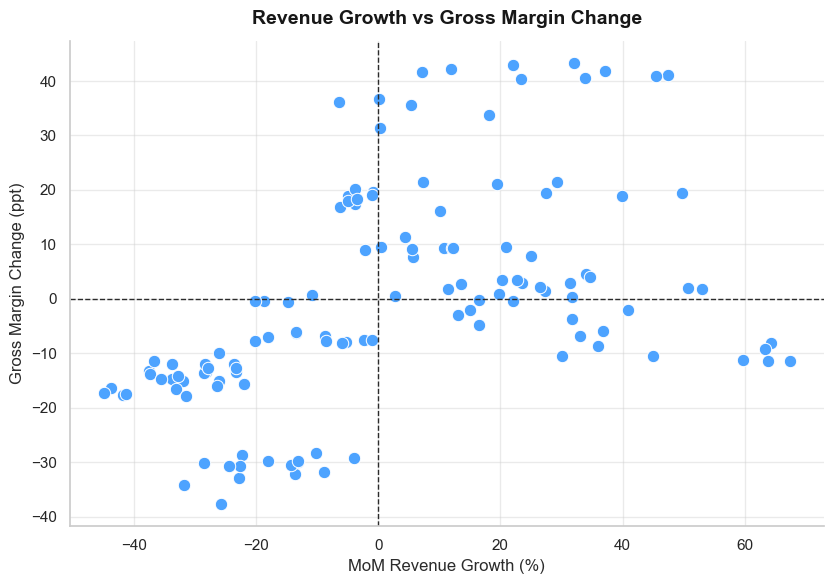

Số tháng revenue tăng nhưng gross margin giảm: 17
Top 10 tháng revenue tăng nhưng gross margin giảm mạnh:


,year_month,revenue,gross_margin,mom_revenue_growth,margin_change
0,2020-03,"104,519,814",8.74%,67.37%,-11.49%
1,2017-03,"175,872,537",7.30%,64.25%,-8.15%
2,2022-03,"129,591,723",6.12%,63.83%,-11.35%
3,2021-03,"106,278,235",8.52%,63.39%,-9.15%
4,2014-03,"173,257,405",9.28%,59.77%,-11.17%
5,2018-03,"159,928,140",9.89%,44.98%,-10.51%
6,2021-02,"65,046,264",17.66%,40.83%,-2.00%
7,2015-03,"160,640,139",9.75%,36.80%,-5.88%
8,2019-03,"113,416,476",8.48%,36.01%,-8.72%
9,2013-03,"141,545,691",8.23%,33.08%,-6.88%


In [435]:
scatter_data = monthly_business.dropna(subset=["mom_revenue_growth", "margin_change"]).copy()

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.scatterplot(
    data=scatter_data,
    x=scatter_data["mom_revenue_growth"] * 100,
    y=scatter_data["margin_change"] * 100,
    s=80,
    color=PALETTE["info_blue"],
    ax=ax,
)
ax.axhline(0, color=PALETTE["dark_gray"], linestyle="--", linewidth=1)
ax.axvline(0, color=PALETTE["dark_gray"], linestyle="--", linewidth=1)
clean_axis(ax, xlabel="MoM Revenue Growth (%)", ylabel="Gross Margin Change (ppt)", title="Revenue Growth vs Gross Margin Change")
plt.tight_layout()
plt.show()

top_margin_pressure_months = margin_pressure_months.loc[
    :, ["year_month", "revenue", "gross_margin", "mom_revenue_growth", "margin_change"]
].head(10).copy()

print("Số tháng revenue tăng nhưng gross margin giảm:", len(margin_pressure_months))
if top_margin_pressure_months.empty:
    print("Không có tháng nào thỏa điều kiện revenue tăng nhưng gross margin giảm.")
else:
    print("Top 10 tháng revenue tăng nhưng gross margin giảm mạnh:")
    display(
        top_margin_pressure_months.assign(
            year_month=top_margin_pressure_months["year_month"].map(format_period),
            revenue=top_margin_pressure_months["revenue"].map(format_currency),
            gross_margin=top_margin_pressure_months["gross_margin"].map(format_pct),
            mom_revenue_growth=top_margin_pressure_months["mom_revenue_growth"].map(format_pct),
            margin_change=top_margin_pressure_months["margin_change"].map(format_pct),
        )
    )


#### Key Findings Template

- Some months show revenue growth while gross margin declined.
- These months may indicate discount-heavy growth, lower-margin product mix, or higher return/refund pressure.
- Business should investigate these periods before scaling similar campaigns.


### 9. Optional: Return impact indicator

Phần này chỉ dùng `returns` để đọc nhanh áp lực refund theo thời gian. Chỉ số này chưa được trừ trực tiếp khỏi revenue chính vì timing refund và timing order có thể khác nhau.


In [436]:
returns_eda = returns.copy()

if not returns_eda.empty and {"return_date", "refund_amount"}.issubset(returns_eda.columns):
    returns_eda["return_date"] = pd.to_datetime(returns_eda["return_date"])
    returns_eda["refund_amount"] = pd.to_numeric(returns_eda["refund_amount"], errors="coerce")
    returns_eda["return_month"] = returns_eda["return_date"].dt.to_period("M").dt.to_timestamp()

    monthly_refunds = (
        returns_eda.groupby("return_month", as_index=False)["refund_amount"]
        .sum()
        .rename(columns={"return_month": "year_month", "refund_amount": "total_refund_amount"})
    )
    refund_indicator = monthly_business[["year_month", "revenue"]].merge(monthly_refunds, on="year_month", how="left")
    refund_indicator["total_refund_amount"] = refund_indicator["total_refund_amount"].fillna(0)
    refund_indicator["refund_rate"] = refund_indicator["total_refund_amount"] / refund_indicator["revenue"].replace(0, np.nan)

    total_refund_amount = refund_indicator["total_refund_amount"].sum()
    overall_refund_rate = total_refund_amount / monthly_business["revenue"].sum()
    top_refund_months = refund_indicator.nlargest(5, "total_refund_amount")[
        ["year_month", "total_refund_amount", "refund_rate"]
    ].copy()

    print("Total refund amount:", format_currency(total_refund_amount))
    print("Refund rate indicator:", format_pct(overall_refund_rate))
    print("Top refund months:")
    display(
        top_refund_months.assign(
            year_month=top_refund_months["year_month"].map(format_period),
            total_refund_amount=top_refund_months["total_refund_amount"].map(format_currency),
            refund_rate=top_refund_months["refund_rate"].map(format_pct),
        )
    )
else:
    print("Bảng returns không đủ dữ liệu để tạo refund impact indicator.")


Total refund amount: 510,598,507
Refund rate indicator: 3.26%
Top refund months:


,year_month,total_refund_amount,refund_rate
34,2015-05,"8,884,003",3.70%
71,2018-06,"8,685,478",3.34%
47,2016-06,"8,577,972",3.50%
46,2016-05,"8,495,853",3.17%
35,2015-06,"8,224,575",3.96%


### 10. Business implications template

#### Business Implications

- Nếu revenue tăng chủ yếu nhờ order volume: Doanh nghiệp nên tập trung vào acquisition, traffic conversion và campaign reach.
- Nếu revenue tăng chủ yếu nhờ AOV: Doanh nghiệp nên tối ưu bundle, upsell, cross-sell và free-shipping threshold.
- Nếu peak season rõ ràng: Doanh nghiệp cần chuẩn bị inventory, campaign calendar, logistics capacity và customer support trước các tháng cao điểm.
- Nếu revenue tăng nhưng gross margin giảm: Cần kiểm tra discount intensity, product mix, return/refund và nhóm sản phẩm kéo margin xuống.
- Nếu gross margin giảm theo thời gian: Cần xem lại chiến lược khuyến mãi, pricing và danh mục sản phẩm.
